In [33]:
# ============================================
# Standard library imports
# ============================================
import re
import sys
import json
import pickle
import logging
import random
import subprocess
import warnings
import collections
import itertools
from pathlib import Path

import gzip

import numpy as np
import pandas as pd

from sklearn import model_selection, metrics

from IPython.display import display

warnings.filterwarnings("ignore")

# ============================================
# Numeric / statistics
# ============================================
import numpy as np
import pandas as pd

import scipy
from scipy import stats
from scipy.stats import rankdata

# ============================================
# Plotting / visualization
# ============================================
import matplotlib as mpl
import matplotlib.pyplot as plt

from matplotlib.ticker import FuncFormatter
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec

import seaborn as sns

from upsetplot import UpSet, from_memberships

# ============================================
# scikit-learn
# ============================================
from sklearn import model_selection, metrics
from sklearn.neighbors import LocalOutlierFactor
from sklearn.inspection import permutation_importance
from sklearn import __version__ as sklearn_version

# ============================================
# Optimization
# ============================================
import optuna

# ============================================
# LightGBM
# ============================================
try:
    import lightgbm as lgb
    from lightgbm import LGBMRegressor
except Exception as e:
    raise RuntimeError(
        "LightGBM is not installed. Please install it with `pip install lightgbm`."
    ) from e

# ============================================
# RNA structure
# Later this can be removed if all structure features are precomputed by script.
# ============================================
import RNA

# ============================================
# Model explanation
# ============================================
import shap

# ============================================
# User utilities
# ============================================
import sylib

# ============================================
# Version info
# ============================================
print(f"python    = {sys.version_info[0]}.{sys.version_info[1]}.{sys.version_info[2]}")
print(f"pandas    = {pd.__version__}")
print(f"numpy     = {np.__version__}")
print(f"scipy     = {scipy.__version__}")
print(f"sklearn   = {sklearn_version}")
print(f"optuna    = {optuna.__version__}")
print(f"lightgbm  = {lgb.__version__}")
print(f"ViennaRNA = {RNA.__version__}")
print(f"sylib     = {sylib.__version__}")

# ============================================
# Logging
# ============================================
logging.root.handlers = []

stream_handler = logging.StreamHandler(sys.stderr)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s %(levelname)8s: %(message)s",
    handlers=[stream_handler],
)

logger = logging.getLogger(__name__)

logging.getLogger("matplotlib").setLevel(logging.WARNING)
logging.getLogger("lightgbm").setLevel(logging.WARNING)

python    = 3.11.15
pandas    = 2.3.3
numpy     = 2.4.6
scipy     = 1.17.1
sklearn   = 1.9.0
optuna    = 4.9.0
lightgbm  = 4.6.0
ViennaRNA = 2.7.2
sylib     = 0.3.0.dev0+ae18bb2


In [34]:
# ============================================
# Global plotting configuration
# ============================================

_PLOT_CFG = {
    "fig_w": 6.0,
    "fig_h": 6.0,
    "dpi": 300,
}


SPECIES_INFO = {
    "AT21": {
        "label": "AT",
        "short": "AT21",
        "color": "#664D0AFF",
        "marker": "o",
    },
    "NB21": {
        "label": "NB",
        "short": "NB21",
        "color": "#7e3131",
        "marker": "^",
    },
    "OS21": {
        "label": "OS",
        "short": "OS21",
        "color": "#13563f",
        "marker": "s",
    },
}

def set_plot_style(
    *,
    base_fontsize=10,
    title_fontsize=12,
    label_fontsize=10,
    tick_fontsize=9,
    legend_fontsize=10,
    dpi=300,
    axes_linewidth=1.2,
    spines_top=True,
    spines_right=True,
    tick_size_major=6,
    tick_dir="out",
    grid=False,
    fig_w=6.0,
    fig_h=6.0,
):
    sns.set_style("ticks")

    mpl.rcParams.update({
        "font.family": "DejaVu Sans",
        "font.size": base_fontsize,

        "axes.titlesize": title_fontsize,
        "axes.labelsize": label_fontsize,

        "xtick.labelsize": tick_fontsize,
        "ytick.labelsize": tick_fontsize,

        "legend.fontsize": legend_fontsize,

        "figure.dpi": dpi,
        "savefig.dpi": dpi,

        "axes.linewidth": axes_linewidth,
        "axes.spines.top": spines_top,
        "axes.spines.right": spines_right,
        "axes.grid": grid,
        "axes.axisbelow": True,

        "xtick.major.size": tick_size_major,
        "ytick.major.size": tick_size_major,
        "xtick.direction": tick_dir,
        "ytick.direction": tick_dir,

        "legend.frameon": False,

        "savefig.bbox": "tight",
        "savefig.transparent": False,
        "figure.autolayout": False,
    })

    _PLOT_CFG.update({
        "fig_w": fig_w,
        "fig_h": fig_h,
        "dpi": dpi,
    })


def make_fig(w=None, h=None, dpi=None):
    W = float(w) if w is not None else _PLOT_CFG["fig_w"]
    H = float(h) if h is not None else _PLOT_CFG["fig_h"]
    D = dpi if dpi is not None else _PLOT_CFG["dpi"]

    fig, ax = plt.subplots(
        figsize=(W, H),
        dpi=D,
    )

    return fig, ax


def _compact_formatter():
    def _fmt(x, _pos=None):
        axx = abs(x)

        if axx >= 1e9:
            s = f"{x / 1e9:.1f}B"
        elif axx >= 1e6:
            s = f"{x / 1e6:.1f}M"
        elif axx >= 1e3:
            s = f"{x / 1e3:.1f}k"
        else:
            s = f"{x:.2g}"

        return (
            s.replace(".0B", "B")
             .replace(".0M", "M")
             .replace(".0k", "k")
        )

    return FuncFormatter(_fmt)


def format_axis(
    ax,
    *,
    xlabel=None,
    ylabel=None,
    compact_ticks=(),
):
    if xlabel is not None:
        ax.set_xlabel(xlabel)

    if ylabel is not None:
        ax.set_ylabel(ylabel)

    fmt = _compact_formatter()

    if "x" in compact_ticks:
        ax.xaxis.set_major_formatter(fmt)

    if "y" in compact_ticks:
        ax.yaxis.set_major_formatter(fmt)

    return ax


# ============================================
# Joint scatter with KDE marginals
# ============================================

def safe_pearsonr(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if len(x) < 2:
        return np.nan, np.nan

    if np.std(x) == 0 or np.std(y) == 0:
        return np.nan, np.nan

    return stats.pearsonr(x, y)


def safe_spearmanr(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if len(x) < 2:
        return np.nan, np.nan

    if np.std(x) == 0 or np.std(y) == 0:
        return np.nan, np.nan

    return stats.spearmanr(x, y)

def _kde_1d(values, lo, hi, num=256):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    grid = np.linspace(lo, hi, num)

    if len(values) < 2:
        return grid, np.zeros_like(grid)

    try:
        kde = stats.gaussian_kde(values)
        dens = kde(grid)
        dens /= dens.max() if dens.max() > 0 else 1
        return grid, dens

    except Exception:
        return grid, np.zeros_like(grid)


def joint_scatter(
    x,
    y,
    *,
    color=None,
    point_size=18,
    alpha=0.65,
    show_identity=True,
    show_regression=True,
    annotate=True,
    annotate_spearman=True,
    xlabel=None,
    ylabel=None,
    title=None,
    figsize=None,
    w=None,
    h=None,
    dpi=None,
    annotate_fontsize=14,
):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    n = len(x)

    if figsize is not None:
        FW, FH = figsize
    else:
        FW = float(w) if w is not None else _PLOT_CFG["fig_w"]
        FH = float(h) if h is not None else _PLOT_CFG["fig_h"]

    fig = plt.figure(
        figsize=(FW, FH),
        dpi=(dpi or _PLOT_CFG["dpi"]),
    )

    gs = GridSpec(
        2,
        2,
        width_ratios=(4, 1),
        height_ratios=(1, 4),
        hspace=0.05,
        wspace=0.05,
    )

    ax_top = fig.add_subplot(gs[0, 0])
    ax_joint = fig.add_subplot(gs[1, 0], sharex=ax_top)
    ax_right = fig.add_subplot(gs[1, 1], sharey=ax_joint)

    ax_joint.scatter(
        x,
        y,
        s=point_size,
        alpha=alpha,
        edgecolor="none",
        color=color,
    )

    lo = float(np.nanmin([x.min(), y.min()]))
    hi = float(np.nanmax([x.max(), y.max()]))

    pad = 0.05 * (hi - lo if hi > lo else 1.0)

    lo -= pad
    hi += pad

    ax_joint.set_xlim(lo, hi)
    ax_joint.set_ylim(lo, hi)

    if show_identity:
        ax_joint.plot(
            [lo, hi],
            [lo, hi],
            ls="--",
            lw=1.2,
            color="0.65",
            zorder=1,
        )

    if show_regression and n >= 2 and np.std(x) > 0 and np.std(y) > 0:
        slope, intercept = np.polyfit(x, y, 1)

        ax_joint.plot(
            [lo, hi],
            slope * np.array([lo, hi]) + intercept,
            color="black",
            lw=1.5,
            zorder=2,
        )

    format_axis(
        ax_joint,
        xlabel=xlabel,
        ylabel=ylabel,
        compact_ticks=(),
    )

    if title:
        ax_joint.set_title(title)

    if annotate and n >= 2 and np.std(x) > 0 and np.std(y) > 0:
        rp, _ = safe_pearsonr(x, y)
        rs, _ = safe_spearmanr(x, y)

        txt = rf"$r_p = {rp:.2f}$"

        if annotate_spearman:
            txt += "\n" + rf"$r_s = {rs:.2f}$"

        txt += f"\n$n = {n}$"

        ax_joint.text(
            0.04,
            0.96,
            txt,
            transform=ax_joint.transAxes,
            ha="left",
            va="top",
            fontsize=annotate_fontsize,
        )

    gx, dx = _kde_1d(x, lo, hi)
    gy, dy = _kde_1d(y, lo, hi)

    ax_top.plot(gx, dx, lw=2, color=color)
    ax_top.axis("off")

    ax_right.plot(dy, gy, lw=2, color=color)
    ax_right.axis("off")

    plt.tight_layout()

    return fig, (ax_joint, ax_top, ax_right)


set_plot_style()

# ============================================
# Plot helper functions
# ============================================

def species_palette():
    return [
        SPECIES_INFO["AT21"]["color"],
        SPECIES_INFO["NB21"]["color"],
        SPECIES_INFO["OS21"]["color"],
    ]


def outside_legend(
    ax,
    *,
    title="Species",
    n_items=3,
    x=1.02,
    y=1.00,
):
    handles, labels = ax.get_legend_handles_labels()

    ax.legend(
        handles[:n_items],
        labels[:n_items],
        title=title,
        frameon=False,
        loc="upper left",
        bbox_to_anchor=(x, y),
        borderaxespad=0,
    )

    return ax

In [35]:

RESULT_DIR = Path("../results")
LGBM_DIR = RESULT_DIR / "lgbm"

SPECIES = ["AT21", "NB21", "OS21"]

species_label = {
    "AT21": "AT",
    "NB21": "NB",
    "OS21": "OS",
}

threshold_feature_file = LGBM_DIR / "lgbm.retention_feature_sets.tsv.gz"

threshold_feature_df = pd.read_csv(
    threshold_feature_file,
    sep="\t",
)

print("Threshold feature sets")
print(threshold_feature_df.shape)

display(
    threshold_feature_df
    .groupby(["Species", "Cutoff"])
    .size()
    .rename("N_features")
    .reset_index()
)

Threshold feature sets
(10842, 3)


,Species,Cutoff,N_features
0,AT,0.00,449
1,AT,0.05,407
2,AT,0.10,373
3,AT,0.15,331
4,AT,0.20,313
5,AT,0.25,283
6,AT,0.30,243
7,AT,0.35,226
8,AT,0.40,189
9,AT,0.45,160


In [36]:
# ============================================
# Load saved LightGBM data bundles
# Inspect available objects
# ============================================

lgbm_bundles = {}

for species_key in SPECIES:
    bundle_file = LGBM_DIR / f"{species_key}.lgbm.data_bundle.pkl.gz"

    with gzip.open(bundle_file, "rb") as f:
        bundle = pickle.load(f)

    lgbm_bundles[species_key] = bundle

    print("=" * 60)
    print(species_key)
    print(f"File : {bundle_file.name}")
    print("Keys :", sorted(bundle.keys()))

    for key, value in bundle.items():
        if hasattr(value, "shape"):
            print(f"{key:25s} {value.shape}")
        elif isinstance(value, (list, tuple)):
            print(f"{key:25s} len={len(value)}")
        else:
            print(f"{key:25s} {type(value).__name__}")

AT21
File : AT21.lgbm.data_bundle.pkl.gz
Keys : ['feature_names', 'model', 'outlier_removal_method', 'score_col_name', 'species', 'test_bool_array', 'test_data_ratio', 'test_idx_array', 'test_metadata', 'train_bool_array', 'train_idx_array', 'train_metadata', 'x_test_model', 'x_test_raw', 'x_train_model', 'x_train_raw', 'x_xform_param_dict', 'xform_method', 'y_test_model', 'y_test_raw', 'y_train_model', 'y_train_raw', 'y_xform_kwargs']
species                   str
model                     str
score_col_name            str
feature_names             len=464
x_train_raw               (5698, 464)
x_test_raw                (1428, 464)
x_train_model             (5698, 464)
x_test_model              (1428, 464)
y_train_raw               (5698,)
y_test_raw                (1428,)
y_train_model             (5698,)
y_test_model              (1428,)
train_metadata            (5698, 7)
test_metadata             (1428, 7)
x_xform_param_dict        dict
y_xform_kwargs            dict
train_idx_arra

In [37]:
# ============================================
# Load full-model baselines and parameters
# ============================================

baseline_rows = []
best_params = {}

for species_key in SPECIES:
    metrics_file = LGBM_DIR / f"{species_key}.lgbm.metrics.tsv"
    params_file = LGBM_DIR / f"{species_key}.lgbm.best_params.tsv"

    metrics_df = pd.read_csv(metrics_file, sep="\t")
    params_df = pd.read_csv(params_file, sep="\t")

    test_row = metrics_df.loc[metrics_df["dataset"].str.lower() == "test"].iloc[0]

    if {"parameter", "value"}.issubset(params_df.columns):
        params = dict(zip(params_df["parameter"], params_df["value"]))
    elif {"Parameter", "Value"}.issubset(params_df.columns):
        params = dict(zip(params_df["Parameter"], params_df["Value"]))
    else:
        params = params_df.iloc[0].dropna().to_dict()

    best_params[species_key] = params

    baseline_rows.append({
        "Species_key": species_key,
        "Species": species_label[species_key],
        "Full_R2": test_row["R2"],
        "Full_Pearson_r": test_row["Pearson_r"],
        "Full_RMSE": test_row["RMSE"],
        "Full_MAE": test_row["MAE"],
    })

baseline_df = pd.DataFrame(baseline_rows)

print("Full-model test baselines")
display(baseline_df)

print("\nSaved LightGBM parameters")
for species_key, params in best_params.items():
    print(species_key, params)

Full-model test baselines


,Species_key,Species,Full_R2,Full_Pearson_r,Full_RMSE,Full_MAE
0,AT21,AT,0.291471,0.541506,0.846832,0.646462
1,NB21,NB,0.294002,0.543576,0.855906,0.649270
2,OS21,OS,0.388360,0.623862,0.765434,0.587098



Saved LightGBM parameters
AT21 {'species': 'AT21', 'model': 'LightGBM', 'best_cv_R2': 0.2504868724505485, 'n_trials': 20, 'k_cv': 10, 'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 13, 'min_child_samples': 28, 'feature_fraction': 0.2, 'num_leaves': 39}
NB21 {'species': 'NB21', 'model': 'LightGBM', 'best_cv_R2': 0.3092222238921906, 'n_trials': 20, 'k_cv': 10, 'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 7, 'min_child_samples': 10, 'feature_fraction': 0.3, 'num_leaves': 31}
OS21 {'species': 'OS21', 'model': 'LightGBM', 'best_cv_R2': 0.3613909751208884, 'n_trials': 20, 'k_cv': 10, 'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 7, 'min_child_samples': 2, 'feature_fraction': 0.7, 'num_leaves': 44}


In [38]:
# ============================================
# Validate threshold-selected model features
# ============================================

validation_rows = []

for species_key in SPECIES:
    species = species_label[species_key]
    bundle = lgbm_bundles[species_key]

    model_features = set(bundle["x_train_model"].columns)
    selected_features = set(threshold_feature_df.loc[threshold_feature_df["Species"] == species, "Feature"])
    missing = selected_features - model_features

    validation_rows.append({
        "Species": species,
        "Model_features": len(model_features),
        "Threshold_features": len(selected_features),
        "Missing_features": len(missing),
    })

    assert not missing, f"{species_key}: missing features {sorted(missing)}"

feature_validation_df = pd.DataFrame(validation_rows)

print("Threshold-feature validation")
display(feature_validation_df)

Threshold-feature validation


,Species,Model_features,Threshold_features,Missing_features
0,AT,464,449,0
1,NB,464,449,0
2,OS,463,449,0


In [39]:
# ============================================
# Reduced-model CV performance
# ============================================

cv_rows = []

for species_key in SPECIES:
    species = species_label[species_key]
    bundle = lgbm_bundles[species_key]

    x_train = bundle["x_train_model"]
    y_train = bundle["y_train_model"]

    saved = best_params[species_key]

    tuned_params = {
        "max_depth": int(saved["max_depth"]),
        "min_child_samples": int(saved["min_child_samples"]),
        "feature_fraction": float(saved["feature_fraction"]),
        "num_leaves": int(saved["num_leaves"]),
    }

    k_cv = int(saved["k_cv"])
    n_estimators = int(saved["n_estimators"])
    learning_rate = float(saved["learning_rate"])

    cv = model_selection.KFold(
        n_splits=k_cv,
        shuffle=True,
        random_state=0,
    )

    full_model = LGBMRegressor(
        objective="regression",
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        random_state=0,
        n_jobs=1,
        verbosity=-1,
        **tuned_params,
    )

    full_scores = model_selection.cross_val_score(
        full_model,
        x_train,
        y_train,
        cv=cv,
        scoring="r2",
        n_jobs=10,
    )

    full_cv_r2 = full_scores.mean()

    for cutoff in sorted(threshold_feature_df["Cutoff"].unique()):

        features = threshold_feature_df.loc[
            (threshold_feature_df["Species"] == species) &
            np.isclose(threshold_feature_df["Cutoff"], cutoff),
            "Feature",
        ].tolist()

        model = LGBMRegressor(
            objective="regression",
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            random_state=0,
            n_jobs=1,
            verbosity=-1,
            **tuned_params,
        )

        scores = model_selection.cross_val_score(
            model,
            x_train[features],
            y_train,
            cv=cv,
            scoring="r2",
            n_jobs=10,
        )

        cv_rows.append({
            "Species": species,
            "Cutoff": cutoff,
            "N_features": len(features),
            "Full_CV_R2": full_cv_r2,
            "Reduced_CV_R2": scores.mean(),
            "CV_R2_SD": scores.std(ddof=1),
        })

retention_cv_df = (
    pd.DataFrame(cv_rows)
    .sort_values(["Species", "Cutoff"])
    .reset_index(drop=True)
)

print("Reduced-model CV performance")
display(retention_cv_df)

Reduced-model CV performance


,Species,Cutoff,N_features,Full_CV_R2,Reduced_CV_R2,CV_R2_SD
0,AT,0.00,449,0.250487,0.246176,0.036747
1,AT,0.05,407,0.250487,0.249711,0.037194
2,AT,0.10,373,0.250487,0.253173,0.038253
3,AT,0.15,331,0.250487,0.253356,0.033886
4,AT,0.20,313,0.250487,0.248637,0.035945
5,AT,0.25,283,0.250487,0.247786,0.033800
6,AT,0.30,243,0.250487,0.253541,0.032040
7,AT,0.35,226,0.250487,0.254394,0.032797
8,AT,0.40,189,0.250487,0.253222,0.037942
9,AT,0.45,160,0.250487,0.255678,0.037721


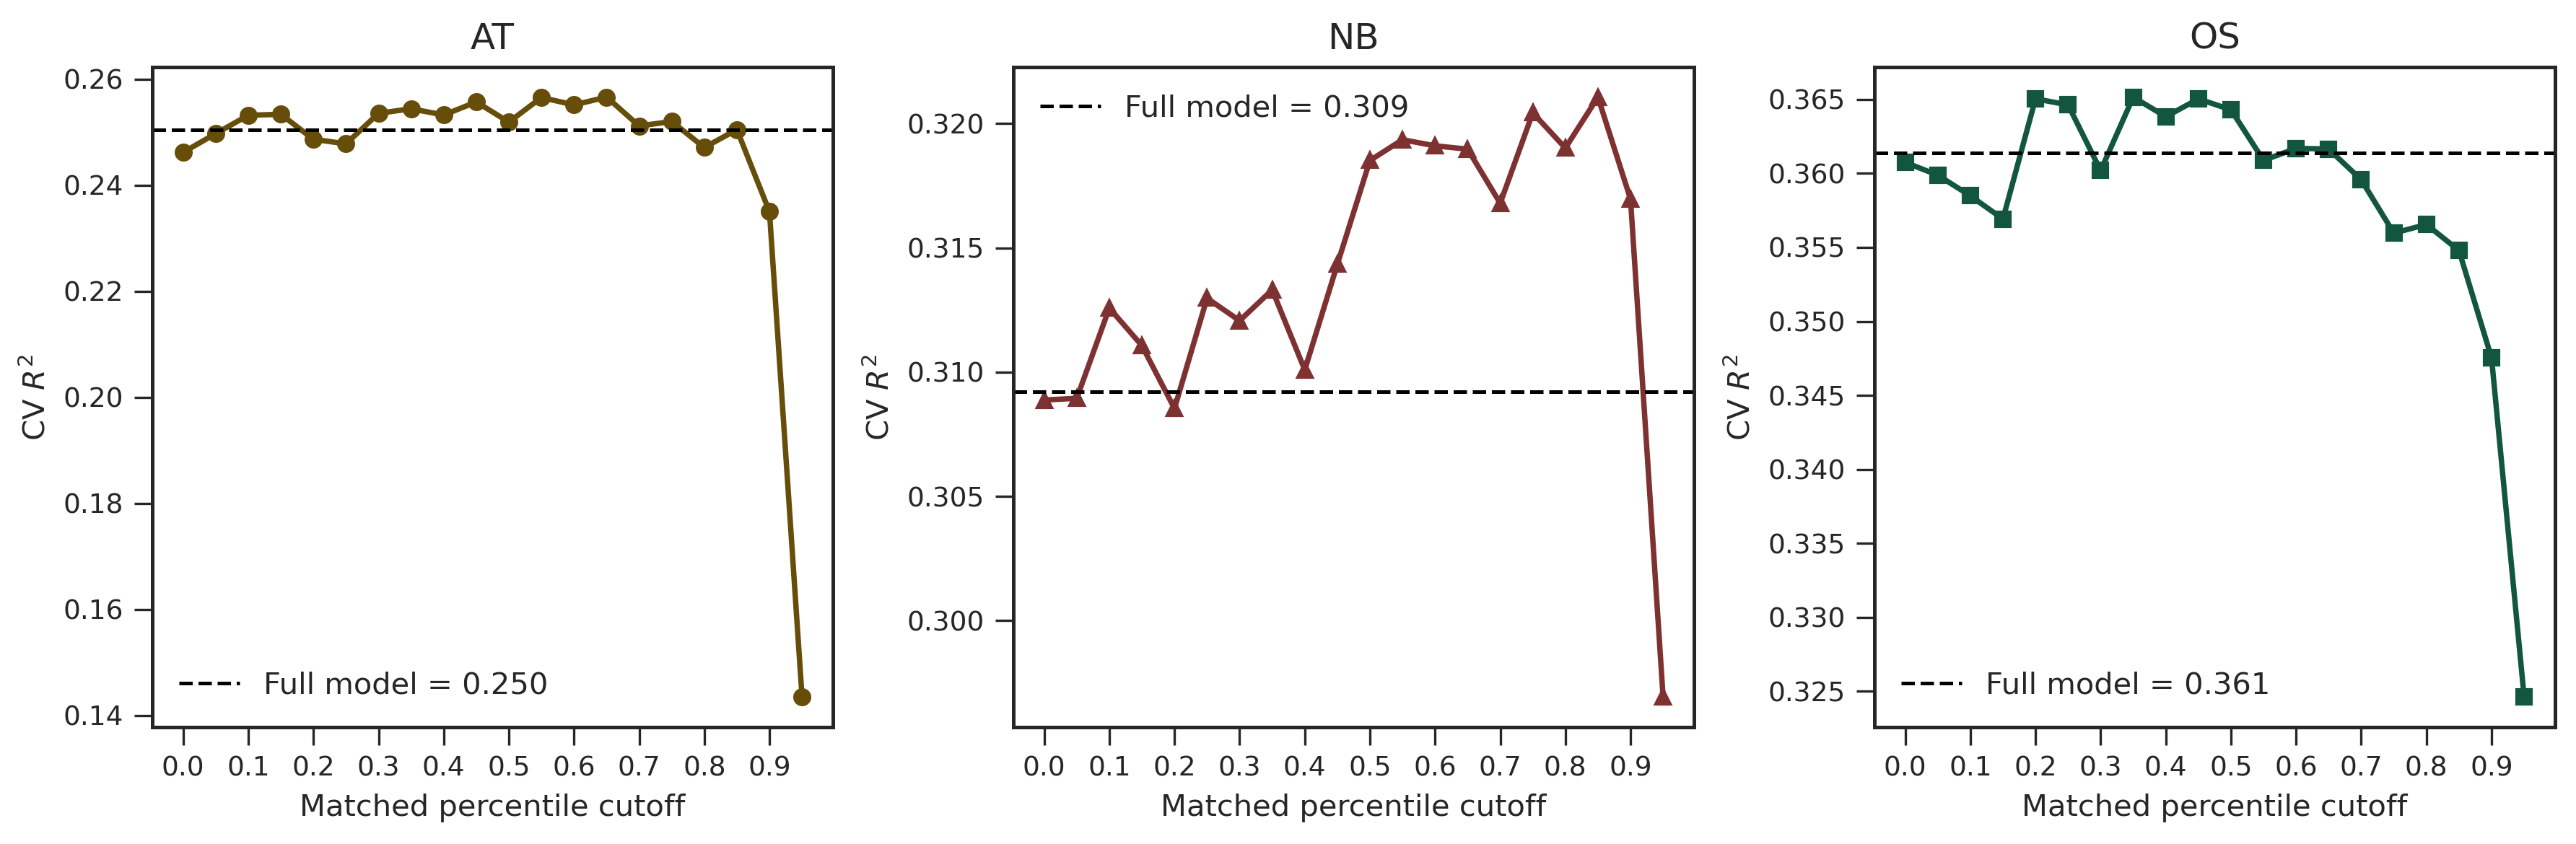

In [40]:
# ============================================
# Reduced-model CV R2 across cutoffs
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(12, 4), dpi=_PLOT_CFG["dpi"])

for ax, species_key in zip(axes, SPECIES):
    species = SPECIES_INFO[species_key]["label"]
    temp = retention_cv_df.loc[retention_cv_df["Species"] == species]
    full_r2 = temp["Full_CV_R2"].iloc[0]

    ax.plot(
        temp["Cutoff"], temp["Reduced_CV_R2"],
        color=SPECIES_INFO[species_key]["color"],
        marker=SPECIES_INFO[species_key]["marker"],
        lw=1.8, ms=5,
    )

    ax.axhline(full_r2, color="black", ls="--", lw=1.2, label=f"Full model = {full_r2:.3f}")

    ax.set_title(species)
    ax.set_xticks(np.arange(0, 1.0, 0.1))
    format_axis(ax, xlabel="Matched percentile cutoff", ylabel="CV $R^2$")
    ax.legend(frameon=False)

plt.tight_layout()
plt.show()

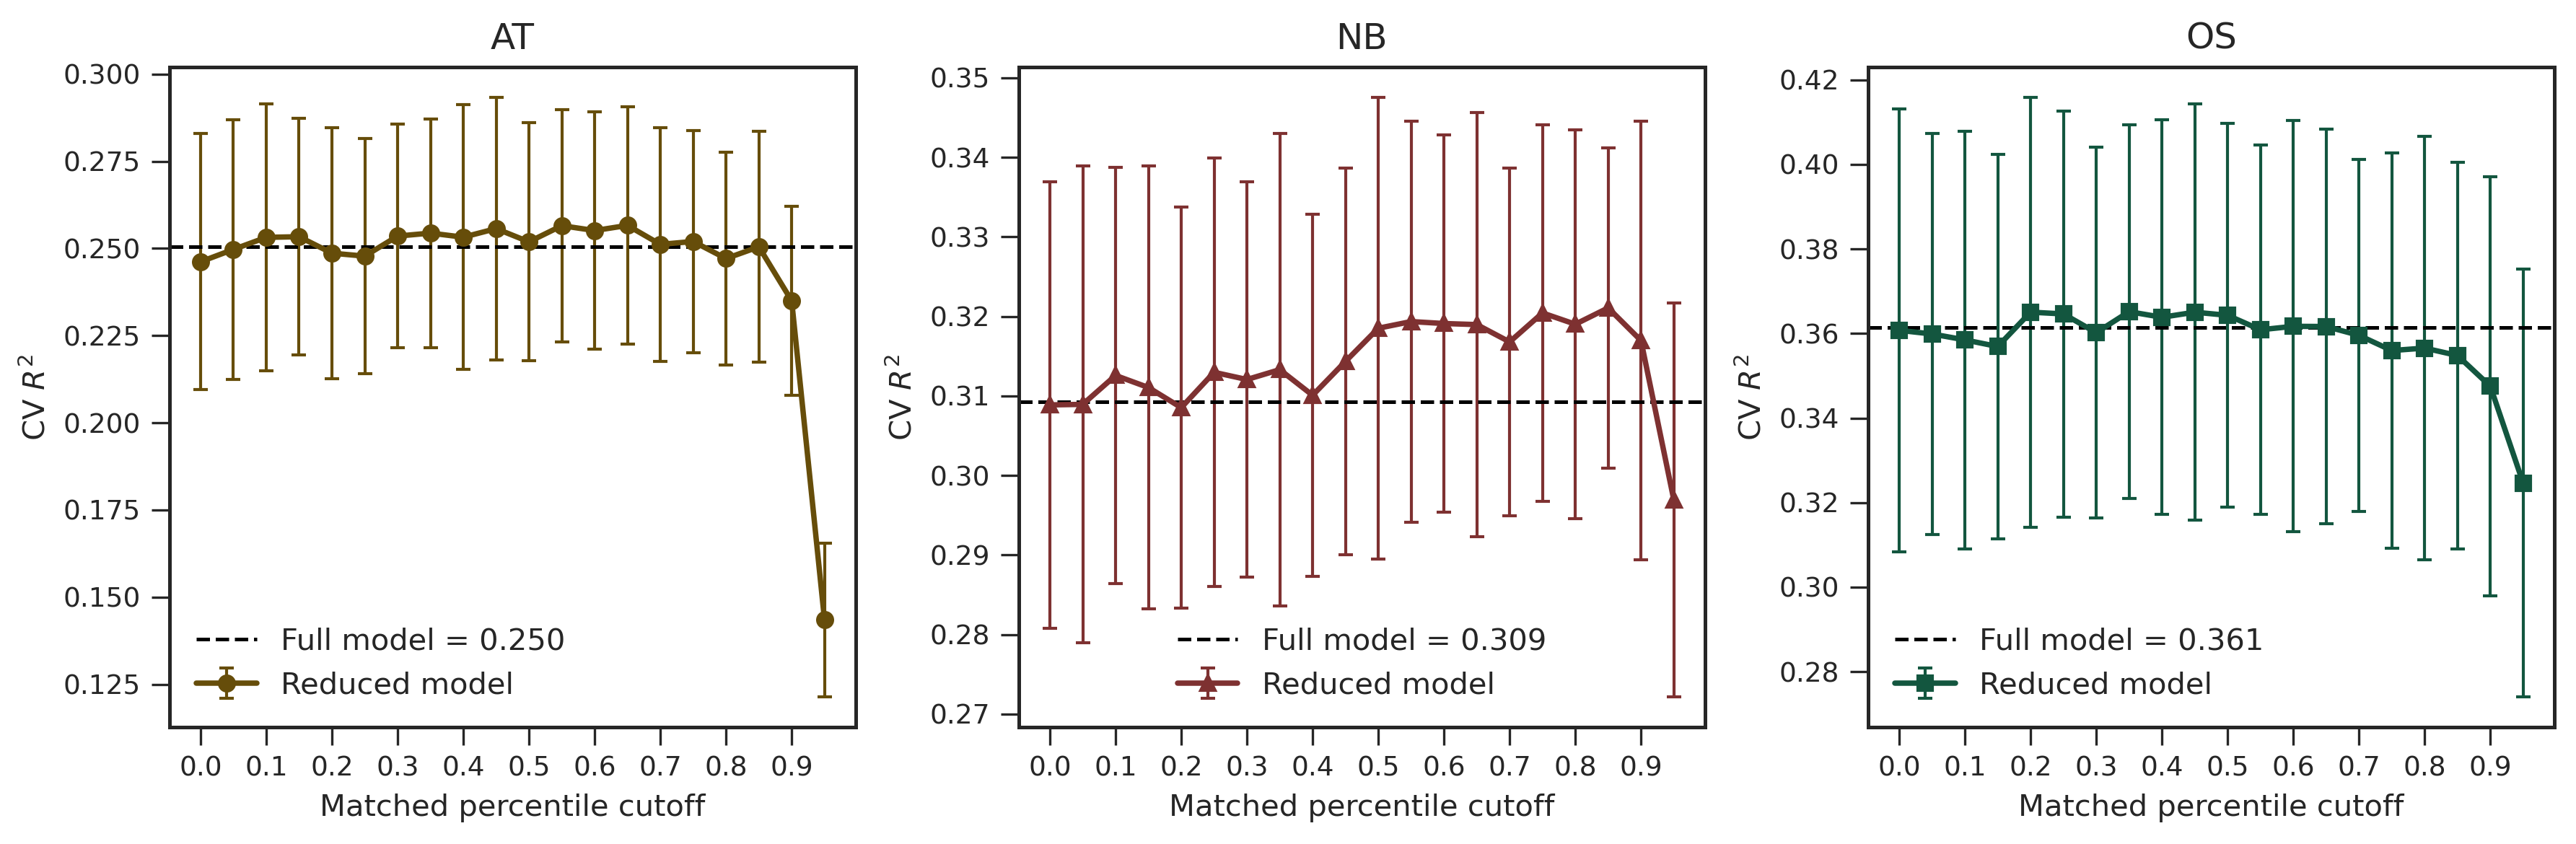

In [41]:
# ============================================
# Reduced-model CV R2 across cutoffs
# Mean ± SD across CV folds
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(12, 4), dpi=_PLOT_CFG["dpi"])

for ax, species_key in zip(axes, SPECIES):
    species = SPECIES_INFO[species_key]["label"]
    temp = retention_cv_df.loc[retention_cv_df["Species"] == species]
    full_r2 = temp["Full_CV_R2"].iloc[0]

    ax.errorbar(
        temp["Cutoff"], temp["Reduced_CV_R2"], yerr=temp["CV_R2_SD"],
        color=SPECIES_INFO[species_key]["color"], marker=SPECIES_INFO[species_key]["marker"],
        lw=1.8, ms=5, capsize=2.5, elinewidth=1, label="Reduced model",
    )

    ax.axhline(full_r2, color="black", ls="--", lw=1.2, label=f"Full model = {full_r2:.3f}")

    ax.set_title(species)
    ax.set_xticks(np.arange(0, 1.0, 0.1))
    format_axis(ax, xlabel="Matched percentile cutoff", ylabel="CV $R^2$")
    ax.legend(frameon=False)

plt.tight_layout()
plt.show()

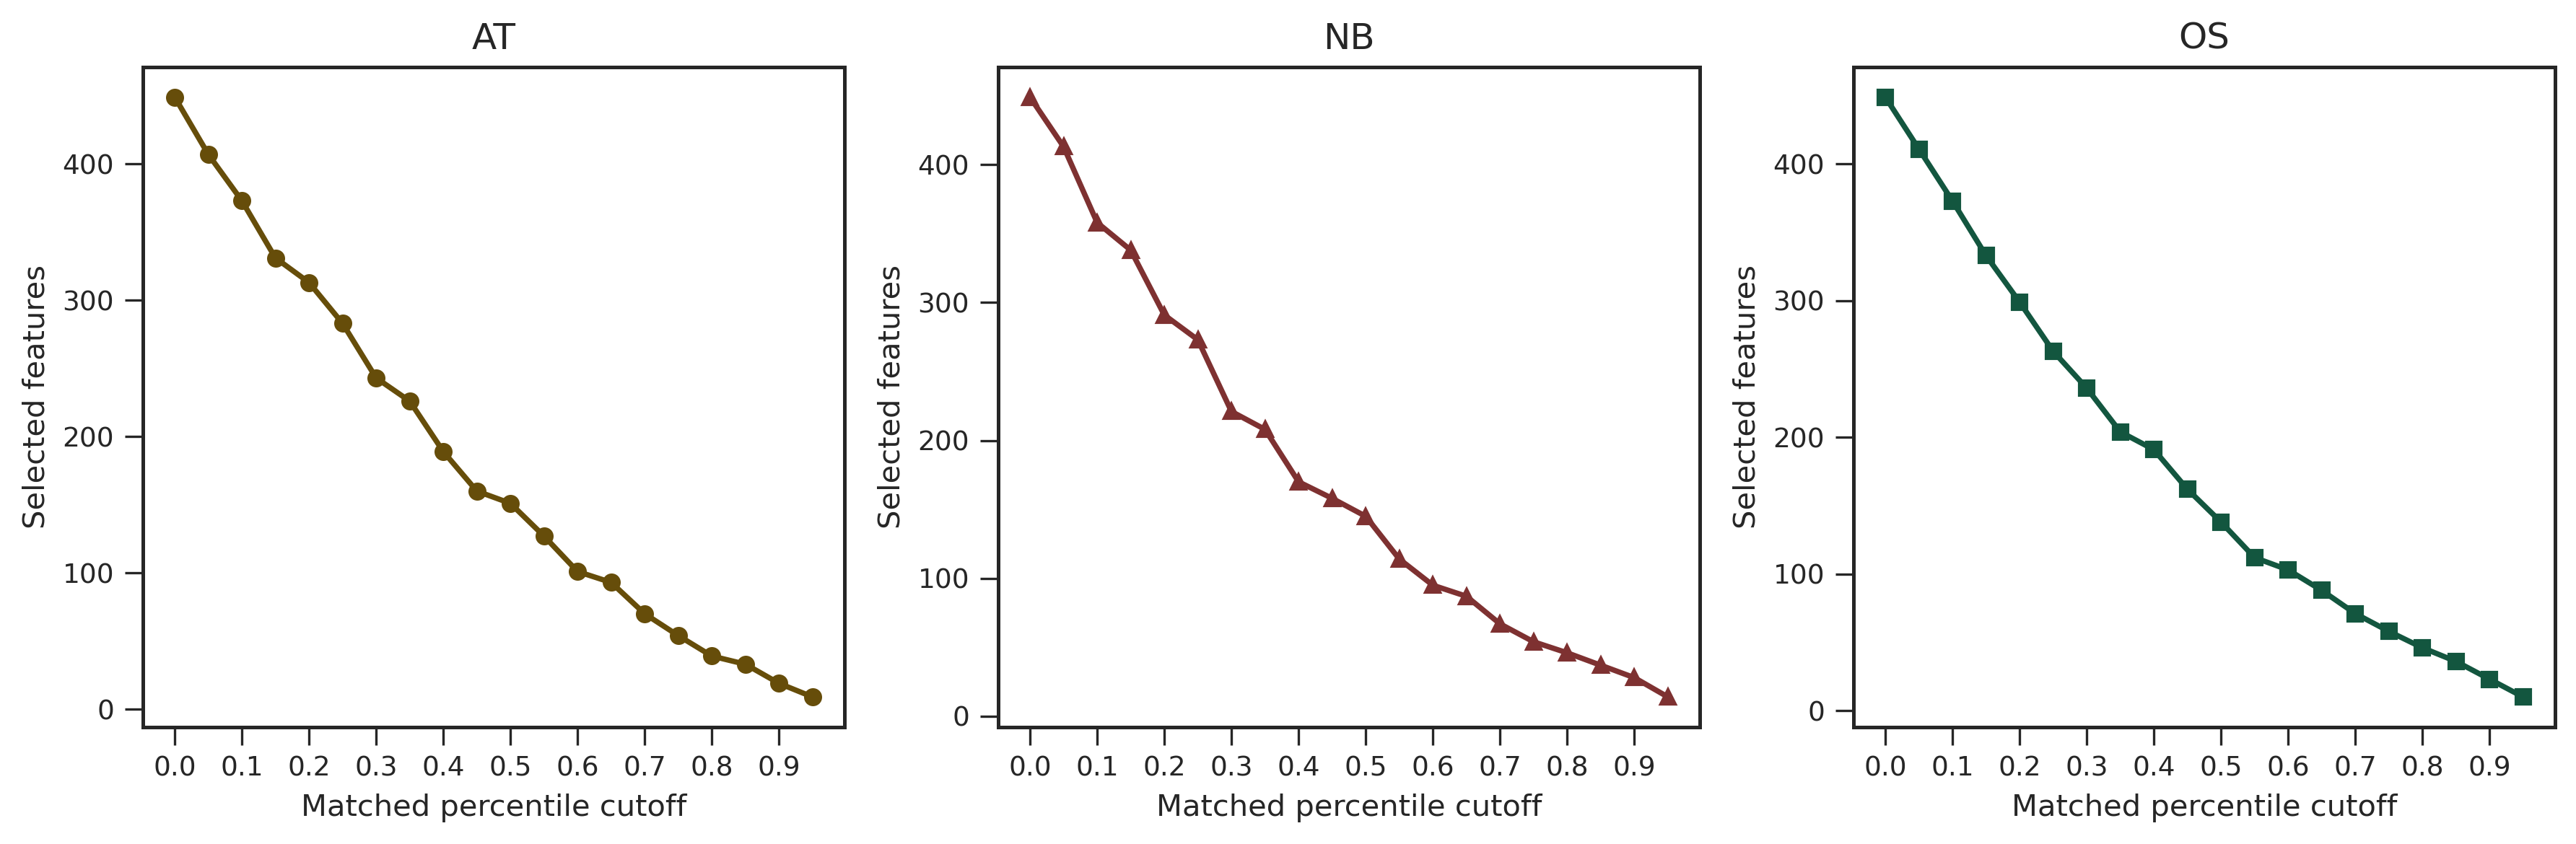

In [42]:
# ============================================
# Selected features across cutoffs
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(12, 4), dpi=_PLOT_CFG["dpi"])

for ax, species_key in zip(axes, SPECIES):
    species = SPECIES_INFO[species_key]["label"]
    temp = retention_cv_df.loc[retention_cv_df["Species"] == species]

    ax.plot(
        temp["Cutoff"], temp["N_features"],
        color=SPECIES_INFO[species_key]["color"],
        marker=SPECIES_INFO[species_key]["marker"],
        lw=1.8, ms=5,
    )

    ax.set_title(species)
    ax.set_xticks(np.arange(0, 1.0, 0.1))
    format_axis(ax, xlabel="Matched percentile cutoff", ylabel="Selected features")

plt.tight_layout()
plt.show()

In [43]:
# ============================================
# Cutoff decision summary
# ============================================

cutoff_summary_df = retention_cv_df.copy()

cutoff_summary_df["Feature_reduction_pct"] = 100 * (
    1 - cutoff_summary_df["N_features"] /
    cutoff_summary_df.groupby("Species")["N_features"].transform("first")
)

cutoff_summary_df["CV_R2_change"] = (
    cutoff_summary_df["Reduced_CV_R2"] -
    cutoff_summary_df["Full_CV_R2"]
)

cutoff_summary_df = cutoff_summary_df.loc[
    cutoff_summary_df["Cutoff"] >= 0.75,
    ["Species", "Cutoff", "N_features", "Feature_reduction_pct",
     "Full_CV_R2", "Reduced_CV_R2", "CV_R2_SD", "CV_R2_change"]
].reset_index(drop=True)

display(cutoff_summary_df.round(4))

,Species,Cutoff,N_features,Feature_reduction_pct,Full_CV_R2,Reduced_CV_R2,CV_R2_SD,CV_R2_change
0,AT,0.75,54,87.9733,0.2505,0.2520,0.0319,0.0015
1,AT,0.80,39,91.3140,0.2505,0.2471,0.0305,-0.0034
2,AT,0.85,33,92.6503,0.2505,0.2505,0.0331,-0.0000
3,AT,0.90,19,95.7684,0.2505,0.2350,0.0272,-0.0155
4,AT,0.95,9,97.9955,0.2505,0.1435,0.0221,-0.1070
5,NB,0.75,54,87.9733,0.3092,0.3204,0.0237,0.0112
6,NB,0.80,46,89.7550,0.3092,0.3190,0.0245,0.0098
7,NB,0.85,37,91.7595,0.3092,0.3211,0.0202,0.0118
8,NB,0.90,28,93.7639,0.3092,0.3170,0.0275,0.0077
9,NB,0.95,14,96.8820,0.3092,0.2969,0.0248,-0.0123


In [44]:
# ============================================
# Inspect missing threshold features
# ============================================

species = "AT"
species_key = "AT21"

model_features = set(lgbm_bundles[species_key]["feature_names"])

threshold_features = set(
    threshold_feature_df.loc[
        (threshold_feature_df["Species"] == species) &
        np.isclose(threshold_feature_df["Cutoff"], 0.0),
        "Feature",
    ]
)

missing = sorted(model_features - threshold_features)

print(f"{species}")
print(f"Model features     : {len(model_features)}")
print(f"Threshold features : {len(threshold_features)}")
print(f"Missing features   : {len(missing)}")

display(missing[:20])

AT
Model features     : 464
Threshold features : 449
Missing features   : 15


["5'UTR.uORF-IO",
 "5'UTR.uORF-OO",
 'CDS.dicodon_AGGCGG',
 'CDS.dicodon_AUACGA',
 'CDS.dicodon_AUACGG',
 'CDS.dicodon_CGAAUA',
 'CDS.dicodon_CGACGA',
 'CDS.dicodon_CGACGG',
 'CDS.dicodon_CGACUG',
 'CDS.dicodon_CGAGCG',
 'CDS.dicodon_CUCAUA',
 'CDS.dicodon_CUCCCG',
 'CDS.dicodon_CUGAUA',
 'CDS.dicodon_GUACCG',
 'CDS.dicodon_GUACGA']

In [45]:
# ============================================
# Inspect missing threshold features
# ============================================

species = "NB"
species_key = "NB21"

model_features = set(lgbm_bundles[species_key]["feature_names"])

threshold_features = set(
    threshold_feature_df.loc[
        (threshold_feature_df["Species"] == species) &
        np.isclose(threshold_feature_df["Cutoff"], 0.0),
        "Feature",
    ]
)

missing = sorted(model_features - threshold_features)

print(f"{species}")
print(f"Model features     : {len(model_features)}")
print(f"Threshold features : {len(threshold_features)}")
print(f"Missing features   : {len(missing)}")

display(missing[:20])

NB
Model features     : 464
Threshold features : 449
Missing features   : 15


["5'UTR.uORF-IO",
 "5'UTR.uORF-OO",
 'CDS.dicodon_AGGCGG',
 'CDS.dicodon_AUACGA',
 'CDS.dicodon_AUACGG',
 'CDS.dicodon_CGAAUA',
 'CDS.dicodon_CGACGA',
 'CDS.dicodon_CGACGG',
 'CDS.dicodon_CGACUG',
 'CDS.dicodon_CGAGCG',
 'CDS.dicodon_CUCAUA',
 'CDS.dicodon_CUCCCG',
 'CDS.dicodon_CUGAUA',
 'CDS.dicodon_GUACCG',
 'CDS.dicodon_GUACGA']

In [46]:
# ============================================
# Inspect missing threshold features
# ============================================

species = "OS"
species_key = "OS21"

model_features = set(lgbm_bundles[species_key]["feature_names"])

threshold_features = set(
    threshold_feature_df.loc[
        (threshold_feature_df["Species"] == species) &
        np.isclose(threshold_feature_df["Cutoff"], 0.0),
        "Feature",
    ]
)

missing = sorted(model_features - threshold_features)

print(f"{species}")
print(f"Model features     : {len(model_features)}")
print(f"Threshold features : {len(threshold_features)}")
print(f"Missing features   : {len(missing)}")

display(missing[:20])

OS
Model features     : 463
Threshold features : 449
Missing features   : 14


["5'UTR.uORF-IO",
 "5'UTR.uORF-OO",
 'CDS.dicodon_AGGCGG',
 'CDS.dicodon_AUACGA',
 'CDS.dicodon_AUACGG',
 'CDS.dicodon_CGAAUA',
 'CDS.dicodon_CGACGA',
 'CDS.dicodon_CGACGG',
 'CDS.dicodon_CGACUG',
 'CDS.dicodon_CGAGCG',
 'CDS.dicodon_CUCAUA',
 'CDS.dicodon_CUCCCG',
 'CDS.dicodon_CUGAUA',
 'CDS.dicodon_GUACCG']